In [ ]:
import numpy as np
from patchsim.src.patchsim.core import model

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
weibull_shape = 3.7
weibull_scale = 120

age_stratification = [i*5 for i in range(80//5)]


In [3]:
age_dist_project = pd.read_csv("age_dist_projected_karnataka.csv")
age_dist_project.head()
total_pop_project = (age_dist_project['Population'][age_dist_project['Age group'] == 'Total']).iloc[0]
age_dist_project['Fraction'] = age_dist_project['Population']/66845
print(total_pop_project)
age_dist_project = age_dist_project.drop(index=17)

66845


(17,)
(16,)


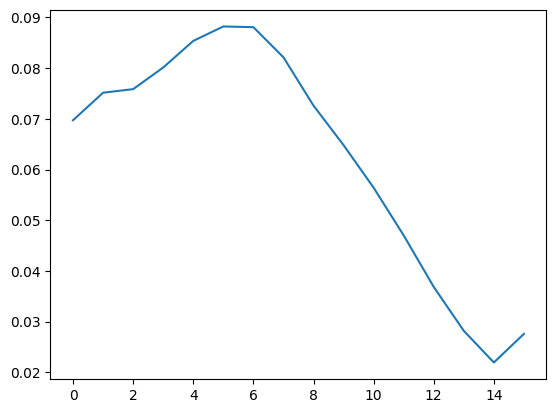

In [4]:
fraction_population = np.copy(age_dist_project['Fraction'].to_numpy())
print(fraction_population.shape)
last_frac = fraction_population[-1]
fraction_population = fraction_population[:-1]
print(fraction_population.shape)
fraction_population[-1]=last_frac+fraction_population[-1]
plt.plot(fraction_population)

In [12]:
districts_to_id = dict()
for i, district in enumerate(districts):
    districts_to_id[district] = i
districts_to_id

{'Bagalakote': 0,
 'Ballari': 1,
 'Belagavi': 2,
 'Bengaluru Rural': 3,
 'Bengaluru Urban': 4,
 'Bidar': 5,
 'Chamarajanagara': 6,
 'Chikkaballapura': 7,
 'Chikkamagaluru': 8,
 'Chitradurga': 9,
 'Dakshina Kannada': 10,
 'Davanagere': 11,
 'Dharwad': 12,
 'Gadag': 13,
 'Hassan': 14,
 'Haveri': 15,
 'Kalaburagi': 16,
 'Kodagu': 17,
 'Kolar': 18,
 'Koppal': 19,
 'Mandya': 20,
 'Mysuru': 21,
 'Raichur': 22,
 'Ramanagara': 23,
 'Shivamogga': 24,
 'Tumakuru': 25,
 'Udupi': 26,
 'Uttara Kannada': 27,
 'Vijayapura': 28,
 'Yadgiri': 29,
 'Others': 30,
 'Karnataka': 31}

In [5]:
# !pip install ipympl

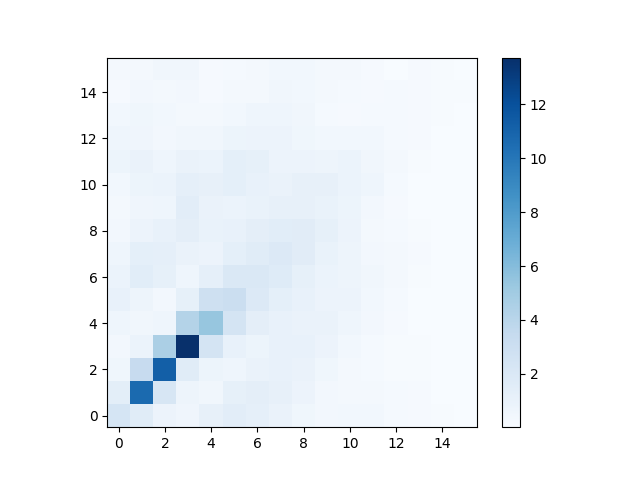

In [9]:
%matplotlib widget
plt.clf()
age_rate_contact_matrix = np.loadtxt('ageinteractionmat.csv')
plt.imshow(age_rate_contact_matrix, cmap ='Blues', origin='lower')
plt.colorbar()
plt.show()

In [13]:
numpatches = len(agegroups_min) * len(districts)
print(numpatches)
numagegroups = len(agegroups_min)
network_matrix_patch = np.zeros((numpatches, numpatches))
for i in range(len(districts)):
    network_matrix_patch[i*numagegroups:(i+1)*numagegroups, i*numagegroups:(i+1)*numagegroups] = age_rate_contact_matrix

96


ValueError: could not broadcast input array from shape (16,16) into shape (3,3)

In [7]:
casesfile = "IRDD_allka.csv"
casesframe = pd.read_csv(casesfile)
districts = casesframe['District'].unique()
print(age_stratification)
agegroups_min = np.array((0, 15, 65 ))
print(casesframe.head(500))
print(casesframe[casesframe['District']=='Bagalakote'])
print(f'Number of distrcits: {len(districts)}')


[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75]
           Date    District  Infected  Recovered  Deceased
0    22-03-2020  Bagalakote         0          0         0
1    23-03-2020  Bagalakote         0          0         0
2    24-03-2020  Bagalakote         0          0         0
3    25-03-2020  Bagalakote         0          0         0
4    26-03-2020  Bagalakote         0          0         0
..          ...         ...       ...        ...       ...
495  30-07-2021  Bagalakote     35092      34725       327
496  31-07-2021  Bagalakote     35096      34730       327
497  01-08-2021  Bagalakote     35096      34732       327
498  02-08-2021  Bagalakote     35102      34734       327
499  03-08-2021  Bagalakote     35103      34736       327

[500 rows x 5 columns]
            Date    District  Infected  Recovered  Deceased
0     22-03-2020  Bagalakote         0          0         0
1     23-03-2020  Bagalakote         0          0         0
2     24-03-2020  Bagalak

In [ ]:
model.NetworkModel()